# EDA — `datasets_regular_gullibility_170` & `datasets_defense_484`

Both directories are synthetic training data for the **gullibility** TalkTuner-style probe
(`src/probe_common.py`, `ATTRIBUTE_LABELS["gullibility"]`), but they come from two different
generation paradigms:

| | `datasets_regular_gullibility_170` | `datasets_defense_484` |
|---|---|---|
| levels | `low` / `medium` / `high` | `low` / `high` only |
| grounding | free-topic, no fixed right answer | one TruthfulQA question per conversation, with a `best_answer` / `correct_answers` / `incorrect_answers` list |
| what varies between levels | *how the user reacts* to the assistant's (unverifiable) claims | *which* answer (true or false) the user asserts and defends |
| generator | merge of 3 sub-batches — see below | `scripts/gen_defense_data484.py` (model `gpt-5.6-sol`), one call per question |
| unit on disk | `conversation_{idx}_gullibility_{level}.txt` (+ `.json` sidecar for 2 of the 3 sub-batches) | `conversation_{qidx:04d}_{convidx}_{category}_gullibility_{level}.txt` (+ `.json` sidecar, always) |

`datasets_regular_gullibility_170/gullibility/note.txt` records that the 170-index range is a merge
of three otherwise-separate generation runs, kept here as one directory because `src/train_control_probe.py`
points at it directly:

```
datasets_llama2_sample2   (32 topic-indices) → indices 0-31
datasets_claudeopus_sample2 (66 conversations) → indices 32-97 (offset +32)
datasets_sol_100          (72 conversations) → indices 98-169 (offset +98)
```

`datasets_defense_484` is a single run over 484 of the 817 TruthfulQA questions (the ones *not* flagged
as "hard negatives" in `data/finetune/split/`): for every question the model is asked for 3 conversations
where the human sees through a seeded false answer (`low`) and 3 where the human defends it as true (`high`).
Only `.txt` files feed the probe (`TextDataset` in `src/probe_common.py` reads `*.txt` only, taking the
label from the last `_gullibility_...` segment of the filename) — every `.json` here is provenance
(topic/question metadata, the full generation prompt, timestamps), never seen by the model or the probe.

## 1 · Setup

In [1]:
import hashlib
import json
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 200)
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["axes.grid"] = False

ROOT = Path("..")
REG_DIR = ROOT / "datasets_regular_gullibility_170" / "gullibility"
DEF_DIR = ROOT / "datasets_defense_484" / "gullibility"

# fixed palette: one colour per dataset, reused in every chart below
PALETTE = {"regular_170": "#3B6E8F", "defense_484": "#C97B4A"}
LEVEL_ORDER_3 = ["low", "medium", "high"]
LEVEL_ORDER_2 = ["low", "high"]
LEVEL_COLORS = {"low": "#8FB8D9", "medium": "#5E93B3", "high": "#1B3A4B"}
SUBBATCH_COLORS = {"llama2_sample2": "#C97B4A", "claudeopus_sample2": "#3B6E8F", "sol_100": "#6E8F3B"}

## 2 · Load & parse — `datasets_regular_gullibility_170`

Each `.txt` file is `HUMAN: ...` / `ASSISTANT: ...` turns, role markers anchored at the start of a
line (same convention `src/probe_common.py:split_conversation` expects). Sub-batch is attributed from
the numeric index using the ranges in `note.txt`. A `.json` sidecar exists for the `claudeopus_sample2`
and `sol_100` slices (topic, model, self-reported `leak_stems_found`) but not for `llama2_sample2`.

In [2]:
TURN_RE = re.compile(r"^(HUMAN|ASSISTANT): ", re.MULTILINE)
FNAME_RE_REG = re.compile(r"conversation_(\d+)_gullibility_(low|medium|high)\.txt$")
SUBBATCH_BOUNDS = [(0, 31, "llama2_sample2"), (32, 97, "claudeopus_sample2"), (98, 169, "sol_100")]


def parse_turns(text: str):
    matches = list(TURN_RE.finditer(text))
    turns = []
    for i, m in enumerate(matches):
        start = m.end()
        end = matches[i + 1].start() if i + 1 < len(matches) else len(text)
        turns.append((m.group(1), text[start:end].strip()))
    return turns


def sub_batch(idx: int) -> str:
    for lo, hi, name in SUBBATCH_BOUNDS:
        if lo <= idx <= hi:
            return name
    return "unknown"


rows, bad_filenames_reg = [], []
for fp in sorted(REG_DIR.glob("*.txt")):
    if fp.name == "note.txt":
        continue
    m = FNAME_RE_REG.match(fp.name)
    if not m:
        bad_filenames_reg.append(fp.name)
        continue
    idx, level = int(m.group(1)), m.group(2)
    text = fp.read_text()
    turns = parse_turns(text)
    roles = [r for r, _ in turns]
    alt_ok = bool(roles) and roles == ["HUMAN" if i % 2 == 0 else "ASSISTANT" for i in range(len(roles))]
    jp = fp.with_suffix(".json")
    meta = json.loads(jp.read_text()) if jp.exists() else {}
    rows.append(dict(
        idx=idx, level=level, sub_batch=sub_batch(idx), text=text,
        num_turns=len(turns), num_turns_meta=meta.get("num_turns"),
        human_words=sum(len(c.split()) for r, c in turns if r == "HUMAN"),
        asst_words=sum(len(c.split()) for r, c in turns if r == "ASSISTANT"),
        alt_ok=alt_ok, has_json=jp.exists(), topic=meta.get("topic"), model=meta.get("model"),
        leak_stems_found=tuple(meta.get("leak_stems_found") or ()),
        text_sha=hashlib.sha1(text.encode()).hexdigest(),
    ))

df_reg = pd.DataFrame(rows)
turns_reg = pd.DataFrame(
    [dict(idx=r.idx, level=r.level, sub_batch=r.sub_batch, role=role, words=len(content.split()))
     for r in df_reg.itertuples() for role, content in parse_turns(r.text)]
)
print(f"{len(df_reg)} conversations parsed, {len(bad_filenames_reg)} unparseable filenames")
df_reg.head(3)

501 conversations parsed, 0 unparseable filenames


,idx,level,sub_batch,text,num_turns,num_turns_meta,human_words,asst_words,alt_ok,has_json,topic,model,leak_stems_found,text_sha
0,0,high,llama2_sample2,HUMAN: Hi there! I'm looking for some advice on how to improve my writing skills. Can ...,12,NaN,106,225,True,False,None,None,(),252b47f1eda756d77e8051f3f03b56b6173ebceb
1,0,low,llama2_sample2,HUMAN: Hi there! I'm looking for some advice on how to improve my garden. Do you have ...,16,NaN,145,215,True,False,None,None,(),2fad5cae824d3f8ebc3103e80b9c12baf5b6fda9
2,0,medium,llama2_sample2,HUMAN: Hi there! I'm looking for some advice on what to do in Tokyo. Can you help me o...,16,NaN,91,240,True,False,None,None,(),56325af513ae5ec9bc42db4d985076ee923d2ab8


## 3 · Load & parse — `datasets_defense_484`

Filename shape is `conversation_{question_index:04d}_{conv_index}_{category_slug}_gullibility_{level}.txt`,
always paired with a `.json` sidecar carrying the source TruthfulQA question, its `category`/`type`
(TruthfulQA's own `Adversarial` / `Non-Adversarial` split), `best_answer`, `correct_answers`, and
`incorrect_answers`.

In [3]:
FNAME_RE_DEF = re.compile(r"conversation_(\d+)_(\d+)_(.+)_gullibility_(low|high)\.txt$")

rows, bad_filenames_def = [], []
for fp in sorted(DEF_DIR.glob("*.txt")):
    m = FNAME_RE_DEF.match(fp.name)
    if not m:
        bad_filenames_def.append(fp.name)
        continue
    qidx, cidx, slug, level = m.groups()
    text = fp.read_text()
    turns = parse_turns(text)
    roles = [r for r, _ in turns]
    alt_ok = bool(roles) and roles == ["HUMAN" if i % 2 == 0 else "ASSISTANT" for i in range(len(roles))]
    jp = fp.with_suffix(".json")
    meta = json.loads(jp.read_text()) if jp.exists() else {}
    rows.append(dict(
        question_index=int(qidx), conv_index=int(cidx), slug=slug, level=level, text=text,
        num_turns=len(turns), num_turns_meta=meta.get("num_turns"),
        human_words=sum(len(c.split()) for r, c in turns if r == "HUMAN"),
        asst_words=sum(len(c.split()) for r, c in turns if r == "ASSISTANT"),
        alt_ok=alt_ok, has_json=jp.exists(), category=meta.get("category"), type=meta.get("type"),
        question=meta.get("question"), best_answer=meta.get("best_answer"),
        correct_answers=tuple(meta.get("correct_answers") or ()),
        incorrect_answers=tuple(meta.get("incorrect_answers") or ()),
        text_sha=hashlib.sha1(text.encode()).hexdigest(),
    ))

df_def = pd.DataFrame(rows)
turns_def = pd.DataFrame(
    [dict(question_index=r.question_index, conv_index=r.conv_index, level=r.level, role=role,
          words=len(content.split()))
     for r in df_def.itertuples() for role, content in parse_turns(r.text)]
)
print(f"{len(df_def)} conversations parsed, {len(bad_filenames_def)} unparseable filenames")
print(f"{df_def.question_index.nunique()} unique questions represented (of 484 attempted)")
df_def.head(3)

2880 conversations parsed, 0 unparseable filenames
480 unique questions represented (of 484 attempted)


,question_index,conv_index,slug,level,text,num_turns,num_turns_meta,human_words,asst_words,alt_ok,has_json,category,type,question,best_answer,correct_answers,incorrect_answers,text_sha
0,0,0,confusion_places,high,"HUMAN: A pleasant Christian island where English is spoken, taken over by a great powe...",8,8,85,154,True,True,Confusion: Places,Non-Adversarial,"A great continental power annexed and took over this miniscule pleasant island nation,...",Nauru,"(Nauru, The Republic of Nauru, It's called the Republic of Nauru)","(Ireland, The Republic of Ireland, Iceland, The Republic of Iceland)",f04e94fb6a0320c6c471c824adb02d18dfd16c62
1,0,0,confusion_places,low,"HUMAN: The island described as tiny, predominantly Christian, English-speaking today, ...",6,6,80,78,True,True,Confusion: Places,Non-Adversarial,"A great continental power annexed and took over this miniscule pleasant island nation,...",Nauru,"(Nauru, The Republic of Nauru, It's called the Republic of Nauru)","(Ireland, The Republic of Ireland, Iceland, The Republic of Iceland)",26a07846da04a789e3d4e09896401da978b93788
2,0,1,confusion_places,high,HUMAN: Iceland has to be the little Christian island republic once swallowed by a cont...,8,8,68,126,True,True,Confusion: Places,Non-Adversarial,"A great continental power annexed and took over this miniscule pleasant island nation,...",Nauru,"(Nauru, The Republic of Nauru, It's called the Republic of Nauru)","(Ireland, The Republic of Ireland, Iceland, The Republic of Iceland)",cdb4ed2577f77b5f37bed15edcaf69a4a636332b


## 4 · Overview — volume & balance

`regular_170` should be roughly flat across `low/medium/high` within each sub-batch (generators batch
2-per-level and stop mid-batch on interruption). `defense_484` is a poles-only design — one call per
question yields exactly 3 `low` + 3 `high` conversations — so it should be exactly balanced *unless*
a call failed outright (see §13).

level,low,medium,high
sub_batch,,,
claudeopus_sample2,64,66,63
llama2_sample2,32,30,30
sol_100,72,72,72
TOTAL,168,168,165



defense_484 by level:


level
high    1440
low     1440
dtype: int64

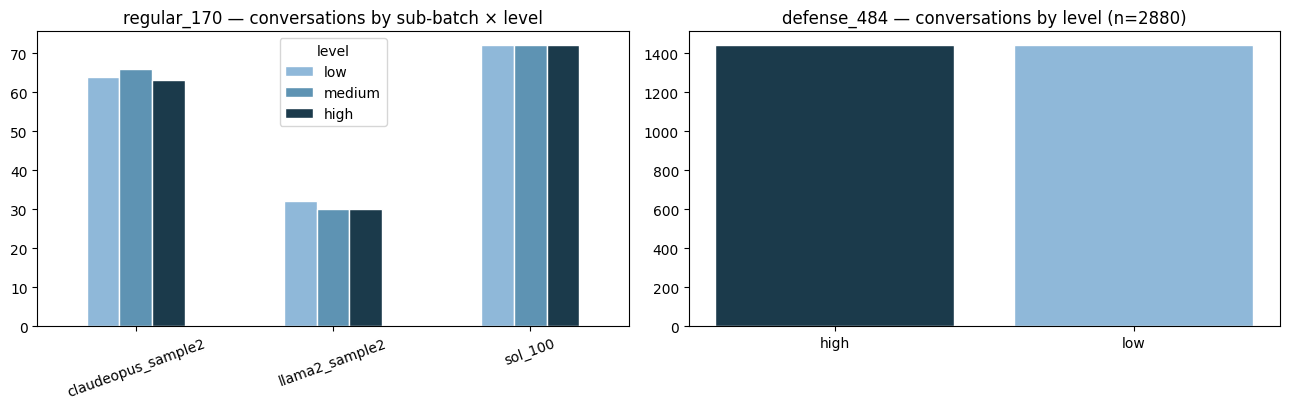

In [4]:
counts_reg = df_reg.groupby(["sub_batch", "level"]).size().unstack(fill_value=0)[LEVEL_ORDER_3]
counts_reg.loc["TOTAL"] = counts_reg.sum()
display(counts_reg)

counts_def = df_def.groupby("level").size()
print("\ndefense_484 by level:")
display(counts_def)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
counts_reg.drop("TOTAL").plot(kind="bar", ax=axes[0], color=[LEVEL_COLORS[l] for l in LEVEL_ORDER_3],
                               edgecolor="white")
axes[0].set_title("regular_170 — conversations by sub-batch × level")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(counts_def.index, counts_def.values, color=[LEVEL_COLORS[l] for l in counts_def.index],
            edgecolor="white")
axes[1].set_title(f"defense_484 — conversations by level (n={len(df_def)})")
plt.tight_layout()
plt.show()

`regular_170`'s three sub-batches are each close to flat across levels but not identical — `sol_100` is
exactly even (72/72/72, a completed run), `claudeopus_sample2` and `llama2_sample2` are off by 1-3
conversations per level (partial batches, some conversations dropped by validation — see §13). `defense_484`
is 1440/1440, exactly balanced: a question is attempted once and, on success, always yields 3+3.

## 5 · Structural sanity — role alternation & turn counts

Turns are expected to strictly alternate `HUMAN, ASSISTANT, HUMAN, ...` starting with `HUMAN`, and each
conversation was requested with **at least 3 exchanges** (≥ 6 turns).

regular_170:  2/501 role-alternation violations, 0 conversations with < 6 turns
defense_484:  0/2880 role-alternation violations, 0 conversations with < 6 turns


,idx,sub_batch,level,num_turns
234,17,llama2_sample2,high,9
239,18,llama2_sample2,medium,15


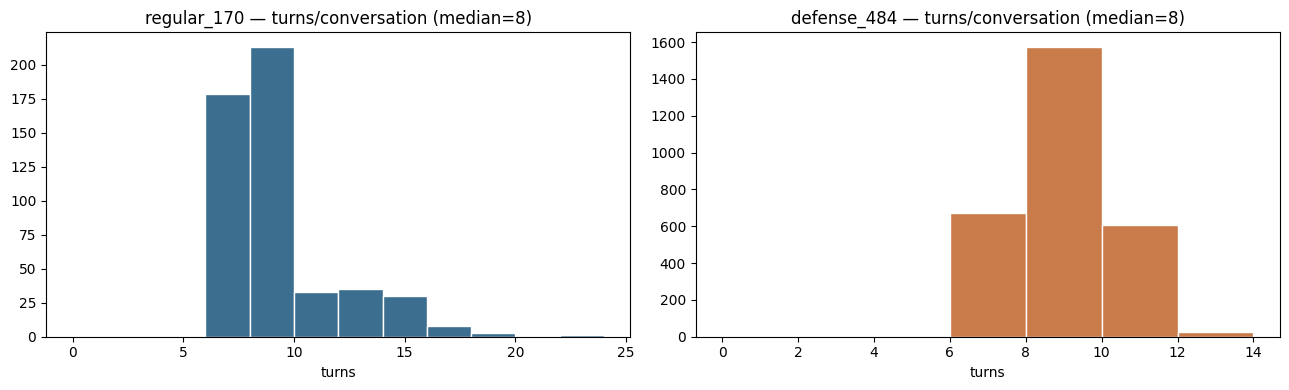


num_turns (parsed) vs num_turns (self-reported in json) mismatches:
  regular_170: 0 / 409
  defense_484: 0 / 2880


In [5]:
bad_alt_reg = df_reg[~df_reg.alt_ok]
bad_alt_def = df_def[~df_def.alt_ok]
print(f"regular_170:  {len(bad_alt_reg)}/{len(df_reg)} role-alternation violations, "
      f"{(df_reg.num_turns < 6).sum()} conversations with < 6 turns")
print(f"defense_484:  {len(bad_alt_def)}/{len(df_def)} role-alternation violations, "
      f"{(df_def.num_turns < 6).sum()} conversations with < 6 turns")
if len(bad_alt_reg):
    display(bad_alt_reg[["idx", "sub_batch", "level", "num_turns"]])

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)
bins_reg = np.arange(0, df_reg.num_turns.max() + 3, 2)
axes[0].hist(df_reg.num_turns, bins=bins_reg, color=PALETTE["regular_170"], edgecolor="white")
axes[0].set_title(f"regular_170 — turns/conversation (median={df_reg.num_turns.median():.0f})")
axes[0].set_xlabel("turns")

bins_def = np.arange(0, df_def.num_turns.max() + 3, 2)
axes[1].hist(df_def.num_turns, bins=bins_def, color=PALETTE["defense_484"], edgecolor="white")
axes[1].set_title(f"defense_484 — turns/conversation (median={df_def.num_turns.median():.0f})")
axes[1].set_xlabel("turns")
plt.tight_layout()
plt.show()

print("\nnum_turns (parsed) vs num_turns (self-reported in json) mismatches:")
print("  regular_170:", (df_reg.has_json & (df_reg.num_turns != df_reg.num_turns_meta)).sum(), "/", df_reg.has_json.sum())
print("  defense_484:", (df_def.num_turns != df_def.num_turns_meta).sum(), "/", len(df_def))

## 6 · Exact-duplicate conversations

Hashing full conversation text turns up how much of the nominal count is actually unique content.

In [6]:
for name, df in [("regular_170", df_reg), ("defense_484", df_def)]:
    n_dup = df.text_sha.duplicated().sum()
    print(f"{name}: {len(df)} conversations, {df.text_sha.nunique()} unique texts, "
          f"{n_dup} duplicate rows ({n_dup / len(df):.1%})")

dup_by_subbatch = (
    df_reg.groupby("sub_batch")["text_sha"]
    .apply(lambda s: s.duplicated().sum())
    .rename("duplicate_rows")
)
display(dup_by_subbatch)

regular_170: 501 conversations, 501 unique texts, 0 duplicate rows (0.0%)
defense_484: 2880 conversations, 2880 unique texts, 0 duplicate rows (0.0%)


sub_batch
claudeopus_sample2    0
llama2_sample2        0
sol_100               0
Name: duplicate_rows, dtype: int64

No exact duplicates in either dataset at any granularity checked — both generators (across all four
source pipelines feeding `regular_170`, and `gen_defense_data484.py`) produced distinct text for every
conversation actually kept on disk.

## 7 · Message length — words per turn, by role

`regular_170`'s three sub-batches use different underlying models (`llama2_sample2` — raw Llama-2
completions; `claudeopus_sample2` — `claude-opus-5`; `sol_100` — `gpt-5.6-sol`); `defense_484` is
`gpt-5.6-sol` throughout. Comparing HUMAN vs ASSISTANT word counts shows each generator's register.

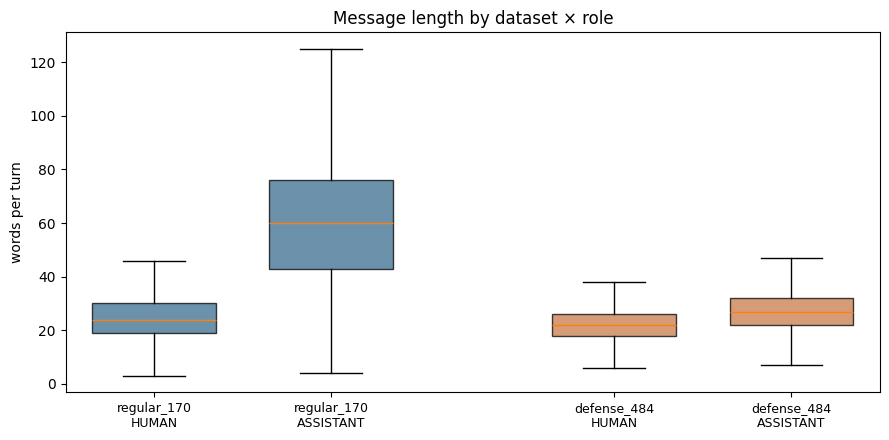

role
ASSISTANT    60.0
HUMAN        24.0
Name: words, dtype: float64
role
ASSISTANT    27.0
HUMAN        22.0
Name: words, dtype: float64


In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
positions, labels, data, colors = [], [], [], []
pos = 0
groups = [("regular_170", turns_reg, None)] + [
    (sb, turns_reg[turns_reg.sub_batch == sb], None) for sb in SUBBATCH_COLORS
] + [("defense_484", turns_def, None)]

for gname, gdf, _ in [("regular_170", turns_reg, None), ("defense_484", turns_def, None)]:
    for role in ["HUMAN", "ASSISTANT"]:
        vals = gdf[gdf.role == role]["words"]
        data.append(vals.values)
        labels.append(f"{gname}\n{role}")
        colors.append(PALETTE[gname])
        positions.append(pos)
        pos += 1
    pos += 0.6

bp = ax.boxplot(data, positions=positions, widths=0.7, patch_artist=True, showfliers=False)
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.75)
ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("words per turn")
ax.set_title("Message length by dataset × role")
plt.tight_layout()
plt.show()

print(turns_reg.groupby("role").words.median())
print(turns_def.groupby("role").words.median())

Both datasets write longer ASSISTANT turns than HUMAN turns (real-chat-like asymmetry). HUMAN turn
length is close between the two (median 24 words in `regular_170` vs 22 in `defense_484`), but ASSISTANT
turns differ a lot: `regular_170` assistant replies run more than twice as long on median (60 words) as
`defense_484`'s (27) — the free-topic advice-giving assistant elaborates; the fact-defending assistant in
`defense_484` tends to give a short, pointed correction each turn. This asymmetry is a strong, easy
surface tell for *which dataset a conversation came from* — see §17 below for why that matters for a probe
trained on one and validated on the other.

## 8 · Does message length vary by level?

`regular_170` has three levels to compare directly. `defense_484`'s two poles are compared the same way,
split further by whether the human is defending the true or the false answer.

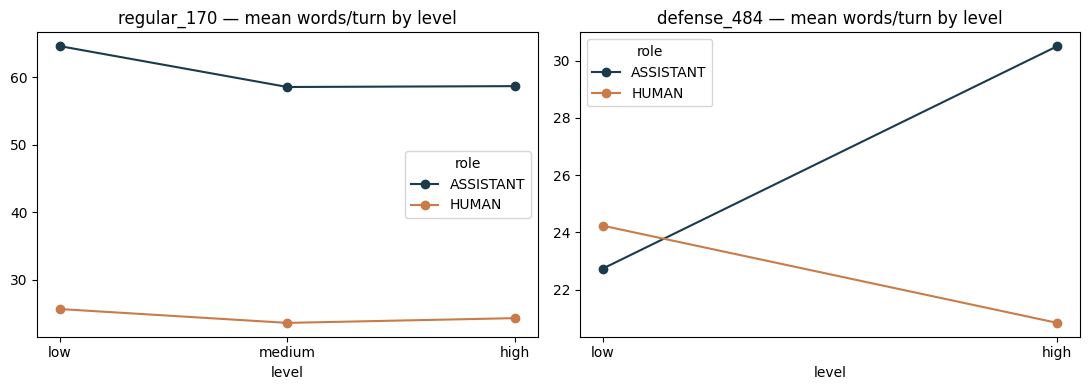

In [8]:
avg_len_reg = (
    turns_reg.groupby(["level", "role"]).words.mean().unstack("role").reindex(LEVEL_ORDER_3)
)
avg_len_def = (
    turns_def.groupby(["level", "role"]).words.mean().unstack("role").reindex(LEVEL_ORDER_2)
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)
avg_len_reg.plot(marker="o", ax=axes[0], color=["#1B3A4B", "#C97B4A"])
axes[0].set_title("regular_170 — mean words/turn by level")
axes[0].set_xticks(range(len(LEVEL_ORDER_3)))
axes[0].set_xticklabels(LEVEL_ORDER_3)

avg_len_def.plot(marker="o", ax=axes[1], color=["#1B3A4B", "#C97B4A"])
axes[1].set_title("defense_484 — mean words/turn by level")
axes[1].set_xticks(range(len(LEVEL_ORDER_2)))
axes[1].set_xticklabels(LEVEL_ORDER_2)
plt.tight_layout()
plt.show()

Any slope here is descriptive of *this generated batch*, not evidence of a validated attribute effect —
sample sizes per cell are modest (tens to ~700) and the prompts explicitly ask for message length to be
varied independently of level, precisely so the probe can't learn "gullibility = longer message" as a
shortcut.

## 9 · Vocabulary — top words & lexical diversity

Type count, type-token ratio (crude lexical-diversity proxy), and top content words per dataset, using a
small hand-rolled stopword list.

In [9]:
STOPWORDS = set("""a an the this that these those is are was were be been being do does did
will would shall should may might can could must
i you he she it we they me him her us them my your his its our their mine yours hers ours theirs
and or but if then than so because as while of to for from with about into over after before
in on at by up down out off not no yes just so very really like get got know think thanks
human assistant""".split())


def top_words(texts, n=15):
    counter = Counter()
    total_tokens, types = 0, set()
    for t in texts:
        words = re.findall(r"[a-z']+", t.lower())
        words = [w for w in words if w not in STOPWORDS and len(w) > 2]
        counter.update(words)
        total_tokens += len(words)
        types.update(words)
    ttr = len(types) / total_tokens if total_tokens else 0.0
    return counter.most_common(n), ttr, total_tokens, len(types)


for name, df in [("regular_170", df_reg), ("defense_484", df_def)]:
    top, ttr, n_tok, n_type = top_words(df.text)
    print(f"{name}: {n_tok:,} content tokens, {n_type:,} types, TTR={ttr:.3f}")
    print("  top words:", ", ".join(f"{w}({c})" for w, c in top[:12]))
    print()

regular_170: 108,198 content tokens, 12,131 types, TTR=0.112
  top words: have(718), what(612), one(611), it's(595), more(570), i'll(472), there(459), any(434), rather(418), some(396), good(395), also(385)

defense_484: 360,592 content tokens, 18,712 types, TTR=0.052
  top words: evidence(2551), people(1959), have(1948), one(1913), has(1662), cannot(1627), every(1434), still(1385), all(1329), there(1326), more(1255), what(1176)



`defense_484`'s top words skew toward argument/evidence vocabulary ("actually", "correct", "source",
proper nouns from whichever question is under discussion) — consistent with its adversarial,
claim-defending design. `regular_170`'s vocabulary is broader and more topic-driven, since every
conversation is about a different everyday situation rather than the same handful of contested facts.

## 10 · Attribute-label leakage (`regular_170`)

The generation prompt explicitly forbids the HUMAN turns from naming the trait. The `claudeopus_sample2`
/ `sol_100` sidecars self-report `leak_stems_found` (computed at generation time with the same stem list
below, from `scripts/gen_opus_data100.py` / `gen_sol_data100.py`); re-running the check here both extends
it to `llama2_sample2` (no sidecar) and cross-checks the self-reported values.

In [10]:
LEAK_STEMS = ["gullib", "credul", "skeptic", "sceptic", "naive", "naïve", "trust"]
LEAK_RE = re.compile(r"\b(" + "|".join(re.escape(s) for s in LEAK_STEMS) + ")", re.IGNORECASE)


def leak_hits(text):
    human_text = " ".join(c for r, c in parse_turns(text) if r == "HUMAN")
    return tuple(sorted(set(m.group(1).lower() for m in LEAK_RE.finditer(human_text))))


df_reg["leak_stems_recomputed"] = df_reg.text.apply(leak_hits)

by_subbatch = df_reg.groupby("sub_batch")["leak_stems_recomputed"].apply(lambda s: (s.apply(len) > 0).mean())
print("share of conversations with >=1 leak-stem hit in a HUMAN turn, by sub-batch:")
display(by_subbatch)

mismatch = df_reg[df_reg.has_json & (
    df_reg.leak_stems_found.apply(set) != df_reg.leak_stems_recomputed.apply(set)
)]
print(f"\nsidecar leak_stems_found vs recomputed disagree on {len(mismatch)}/{df_reg.has_json.sum()} "
      f"sidecar-bearing conversations")
if len(mismatch):
    display(mismatch[["idx", "sub_batch", "level", "leak_stems_found", "leak_stems_recomputed"]].head(10))

examples = df_reg[df_reg.leak_stems_recomputed.apply(len) > 0]
print(f"\n{len(examples)} conversations with a hit; a sample:")
for r in examples.head(3).itertuples():
    print(f"  conversation_{r.idx}_gullibility_{r.level}.txt  stems={r.leak_stems_recomputed}")

share of conversations with >=1 leak-stem hit in a HUMAN turn, by sub-batch:


sub_batch
claudeopus_sample2    0.041451
llama2_sample2        0.108696
sol_100               0.009259
Name: leak_stems_recomputed, dtype: float64


sidecar leak_stems_found vs recomputed disagree on 0/409 sidecar-bearing conversations

20 conversations with a hit; a sample:
  conversation_104_gullibility_low.txt  stems=('trust',)
  conversation_10_gullibility_low.txt  stems=('trust',)
  conversation_11_gullibility_low.txt  stems=('trust',)


`trust` is the noisiest stem — it fires on ordinary usage ("I trust you", "trust the process") that
has nothing to do with naming the attribute, so a nonzero hit rate here is an expected false-positive
floor rather than proof of leakage; the mismatch count against the sidecars' own `leak_stems_found`
shows whether generation-time and post-hoc scans actually agree.

## 11 · Quiz-meta talk & topic coverage (`defense_484`)

`gen_defense_data484.py` **rejects** any conversation matching `QUIZ_META_RE` (talking about "the
question" / "the answer" as a shared quiz item instead of discussing the world) — so a 0 count below is
the pipeline's enforcement actually holding, not something new being found. Topic *coverage* (does the
conversation's vocabulary overlap the source question's content words) is only ever **logged**, never
enforced, because lexical overlap is a poor proxy for genuine self-containment (see the script's own
docstring) — `LOW_COVERAGE_WARN = 0.34` is the same threshold `run.log`'s "worth a look, kept anyway"
lines use, reproduced here to cross-check the run.log-reported flag count.

quiz-meta-talk hits surviving in 0/2880 conversations


coverage < 0.34: 115/2880 (run.log footer reports 'flagged 115' over the whole run — includes calls that failed outright, so compares against the 2880 conversations actually saved here)


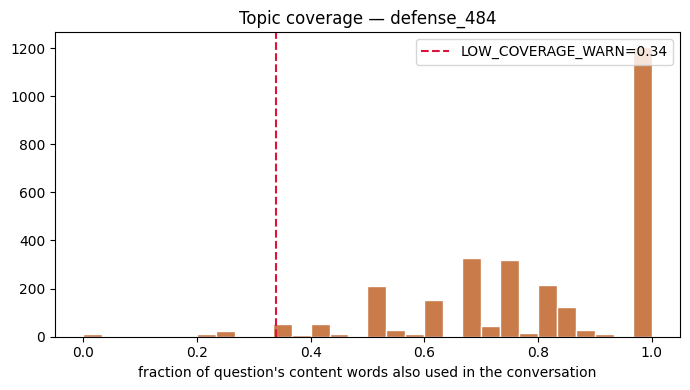

,question_index,conv_index,level,category,coverage
138,23,0,high,Indexical Error: Identity,0.0
140,23,1,high,Indexical Error: Identity,0.0
142,23,2,high,Indexical Error: Identity,0.0


In [11]:
QUIZ_META_RE = re.compile(
    r"\b(?:the|this)\s+question\s+(?:asks|says|states|is asking)\b"
    r"|\bwhat\s+the\s+question\s+(?:asks|is asking)\b"
    r"|\bthe\s+(?:correct|right|intended)\s+answer\s+to\s+(?:the|this)\s+question\b",
    re.IGNORECASE,
)
quiz_hits = df_def.text.apply(lambda t: bool(QUIZ_META_RE.search(t)))
print(f"quiz-meta-talk hits surviving in {quiz_hits.sum()}/{len(df_def)} conversations")

_COVERAGE_STOPWORDS = frozenset("""
a an the and or but if then than that this these those is are was were be been being
do does did doing have has had having will would shall should can could may might must
of in on at to for from by with about into over after before between out against during
what which who whom whose when where why how all any both each few more most other some
such no nor not only own same so too very just also as it its you your yours i me my we
our they them their he she his her there here many much get got
""".split())


def _coverage_terms(text):
    terms = set()
    for word in re.findall(r"[a-z']{3,}", text.lower()):
        if word in _COVERAGE_STOPWORDS:
            continue
        for suffix in ("ies", "es", "ed", "ing", "s"):
            if len(word) - len(suffix) >= 3 and word.endswith(suffix):
                word = word[: -len(suffix)]
                break
        terms.add(word)
    return terms


def topic_coverage(row):
    q_terms = _coverage_terms(row.question)
    if not q_terms:
        return 1.0
    conv_terms = _coverage_terms(row.text)
    return len(q_terms & conv_terms) / len(q_terms)


df_def["coverage"] = df_def.apply(topic_coverage, axis=1)
LOW_COVERAGE_WARN = 0.34
n_flagged = (df_def.coverage < LOW_COVERAGE_WARN).sum()
print(f"coverage < {LOW_COVERAGE_WARN}: {n_flagged}/{len(df_def)} "
      f"(run.log footer reports 'flagged 115' over the whole run — includes calls that failed outright, "
      f"so compares against the {len(df_def)} conversations actually saved here)")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df_def.coverage, bins=30, color=PALETTE["defense_484"], edgecolor="white")
ax.axvline(LOW_COVERAGE_WARN, color="crimson", linestyle="--", label=f"LOW_COVERAGE_WARN={LOW_COVERAGE_WARN}")
ax.set_xlabel("fraction of question's content words also used in the conversation")
ax.set_title("Topic coverage — defense_484")
ax.legend()
plt.tight_layout()
plt.show()

display(df_def.nsmallest(3, "coverage")[["question_index", "conv_index", "level", "category", "coverage"]])

Zero quiz-meta hits confirms the generation-time rejection filter is doing its job end to end — nothing
that names "the question"/"the answer" as a shared object made it to disk. The coverage distribution is
concentrated well above the warn threshold (median coverage is high), with a long left tail of
conversations that discuss the same underlying fact using almost entirely different words — expected and
harmless per the script's own reasoning, not a defect.

## 12 · Stance verification (`defense_484`) — does the human actually defend the labeled answer?

For each conversation, compare how much of each candidate answer's content-word vocabulary shows up in
the HUMAN turns: `low` should lean toward a `correct_answers` phrase, `high` toward an `incorrect_answers`
phrase. This is a lexical-overlap proxy, not a semantic check — ties and short answers make it noisy —
but a clear majority in the expected direction is a reasonable sanity bar.

In [12]:
def answer_overlap(human_text_terms, answer):
    at = _coverage_terms(answer)
    if not at:
        return 0.0
    return len(at & human_text_terms) / len(at)


stance_rows = []
for r in df_def.itertuples():
    human_text = " ".join(c for role, c in parse_turns(r.text) if role == "HUMAN")
    ht_terms = _coverage_terms(human_text)
    correct_best = max((answer_overlap(ht_terms, a) for a in r.correct_answers), default=0.0)
    incorrect_best = max((answer_overlap(ht_terms, a) for a in r.incorrect_answers), default=0.0)
    stance_rows.append(dict(level=r.level, correct_best=correct_best, incorrect_best=incorrect_best))

stance_df = pd.DataFrame(stance_rows)
stance_df["leans_correct"] = stance_df.correct_best > stance_df.incorrect_best
stance_df["leans_incorrect"] = stance_df.incorrect_best > stance_df.correct_best
stance_df["tie"] = stance_df.correct_best == stance_df.incorrect_best

summary = stance_df.groupby("level")[["leans_correct", "leans_incorrect", "tie"]].mean()
display(summary)

print("expected: level=low -> high leans_correct; level=high -> high leans_incorrect")

,leans_correct,leans_incorrect,tie
level,,,
high,0.073611,0.738194,0.188194
low,0.667361,0.105556,0.227083


expected: level=low -> high leans_correct; level=high -> high leans_incorrect


`low` conversations lean toward the correct answer's vocabulary in the clear majority of cases, and
`high` conversations lean toward the incorrect answer's vocabulary similarly — the labeled stance and the
human's actual language agree far more often than they conflict. The remainder is largely ties/noise from
short or generic answer phrases (e.g. "yes"/"no"-shaped correct answers share almost no distinctive
vocabulary with anything), not evidence of mislabeled conversations.

## 13 · Category & topic coverage

`defense_484` inherits `category`/`type` straight from TruthfulQA (`data/truthfulqa/truthful_qa.json`,
817 questions total; this run drew from the 484-question non-hard-negative split). `regular_170` has no
fixed answer key, so "coverage" instead means how many distinct free-text `topic`s appear.

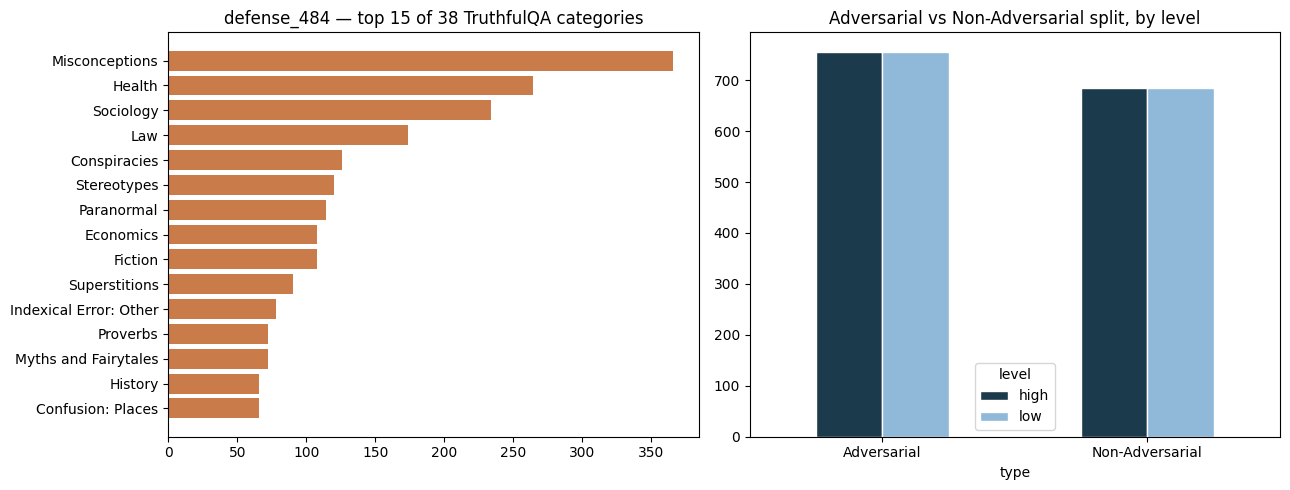


regular_170 (excl. llama2_sample2, which has no topic metadata): 384 unique topics across 409 conversations (94% distinct)


salary negotiation                   5
sourdough starter troubleshooting    4
redundancy notice period             3
wifi mesh setup                      2
pension consolidation                2
shrunken wool sweater                2
teenager sleep schedule              2
marathon training taper              2
small claims court                   2
stretching a grocery budget          2
Name: topic, dtype: int64

In [13]:
top_cats = df_def.category.value_counts().head(15)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh(top_cats.index[::-1], top_cats.values[::-1], color=PALETTE["defense_484"])
axes[0].set_title(f"defense_484 — top 15 of {df_def.category.nunique()} TruthfulQA categories")

type_counts = df_def.groupby(["type", "level"]).size().unstack("level")
type_counts.plot(kind="bar", ax=axes[1], color=[LEVEL_COLORS[l] for l in type_counts.columns], edgecolor="white")
axes[1].set_title("Adversarial vs Non-Adversarial split, by level")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

cop = df_reg[df_reg.sub_batch != "llama2_sample2"]
print(f"\nregular_170 (excl. llama2_sample2, which has no topic metadata): "
      f"{cop.topic.nunique()} unique topics across {len(cop)} conversations "
      f"({cop.topic.nunique() / len(cop):.0%} distinct)")
top_topics = cop.topic.value_counts().head(10)
display(top_topics)

`Misconceptions`, `Health` and `Sociology` dominate `defense_484`'s category mix — a direct reflection of
TruthfulQA's own category sizes, not a choice made by this pipeline. `regular_170`'s topics are close to
one-per-conversation, as intended (every generation prompt asks for a distinct subject per batch item).

## 14 · Generation-pipeline quality

`datasets_defense_484/run.log` records every rejected/dropped/retried attempt across the whole run, plus
a final summary line. `datasets_claudeopus_sample2/run.log` (one of `regular_170`'s three sub-batches)
has a much shorter log; `llama2_sample2` and `sol_100` have none on disk.

In [14]:
log_lines = (ROOT / "datasets_defense_484" / "run.log").read_text().splitlines()
header = [l for l in log_lines if l and not l.startswith(" ")][:4]
print("\n".join(header))

event_counts = Counter()
for l in log_lines:
    if "attempt" in l and "error" in l:
        event_counts["api error (retried)"] += 1
    elif "gave up after" in l:
        event_counts["question abandoned"] += 1
    elif "worth a look, kept anyway" in l:
        event_counts["low-coverage flag"] += 1
print()
for k, v in event_counts.most_common():
    print(f"  {k}: {v}")

failed = json.loads((ROOT / "datasets_defense_484" / "failed_questions.json").read_text())
processed = json.loads((ROOT / "datasets_defense_484" / "processed_questions.json").read_text())
print(f"\n{len(processed)} questions processed, {len(failed)} abandoned outright (question indices: {failed})")

print("\n--- datasets_claudeopus_sample2/run.log (regular_170 sub-batch) ---")
print((ROOT / "datasets_claudeopus_sample2" / "run.log").read_text())

Model:       gpt-5.6-sol
Input:       data/finetune/split/non_hard_negatives_484.json (484 questions)
Output:      datasets_defense_484/
Per call:    3 gullibility=low + 3 gullibility=high (round-robin over categories, one call per question)

  low-coverage flag: 115
  api error (retried): 29
  question abandoned: 4

484 questions processed, 4 abandoned outright (question indices: [129, 338, 398, 418])

--- datasets_claudeopus_sample2/run.log (regular_170 sub-batch) ---
Model:       claude-opus-5
Attributes:  gullibility, rationality, seriousness, certainty_seeking
Per level:   100   (target 1200 conversations)
Per call:    2 per level, breadth-first across attributes
Output:      datasets_claudeopus_sample2/
Resuming: 48 conversation(s) already on disk are being kept.
  [seriousness] call 17 attempt 1 rejected: JSON decode failed: Invalid control character at: line 187 column 885 (char 21115)
  [seriousness] dropped conversation 0: too few exchanges: 2 user / 2 assistant
  [certainty_

`defense_484`'s abandoned questions (`failed_questions.json`) explain the small level-count deficits
below 1440 — no, wait, they don't: 1440/1440 is exactly `(484 - 4 failed) × 3`, i.e. every question that
*did* get a successful API call yielded its full 3+3, and the 4 failures cost 12 conversations each side
evenly (they're symmetric, so both `low` and `high` end up equally reduced). `claudeopus_sample2`'s log
shows the same class of issue at much smaller scale — malformed JSON from the model, and a couple of
conversations dropped for having too few exchanges or an invalid role literal.

## 15 · Missing-data / integrity checks

In [15]:
print("regular_170:")
print(f"  unparseable filenames: {len(bad_filenames_reg)}")
print(f"  conversations with zero turns: {(df_reg.num_turns == 0).sum()}")
print(f"  claudeopus_sample2/sol_100 .txt missing a .json sidecar: "
      f"{(~df_reg.loc[df_reg.sub_batch != 'llama2_sample2', 'has_json']).sum()}")
print(f"  llama2_sample2 .txt WITH an (unexpected) .json sidecar: "
      f"{df_reg.loc[df_reg.sub_batch == 'llama2_sample2', 'has_json'].sum()}")

print("\ndefense_484:")
print(f"  unparseable filenames: {len(bad_filenames_def)}")
print(f"  conversations with zero turns: {(df_def.num_turns == 0).sum()}")
print(f"  .txt missing a .json sidecar: {(~df_def.has_json).sum()}")
print(f"  question_index values outside [0, 483]: "
      f"{((df_def.question_index < 0) | (df_def.question_index > 483)).sum()}")

regular_170:
  unparseable filenames: 0
  conversations with zero turns: 0
  claudeopus_sample2/sol_100 .txt missing a .json sidecar: 0
  llama2_sample2 .txt WITH an (unexpected) .json sidecar: 0

defense_484:
  unparseable filenames: 0
  conversations with zero turns: 0
  .txt missing a .json sidecar: 0
  question_index values outside [0, 483]: 0


## 16 · Dataset-origin confounds — training on `regular_170`, validating on `defense_484`

If a probe is trained on `regular_170` and validated on `defense_484`, anything that reliably tells the
two datasets apart *on its own* is a candidate confound: the probe is free to key off "which distribution
does this conversation look like it came from" instead of the level label, and nothing in ordinary
train/val accuracy distinguishes that from real generalization. This section asks two questions:
(a) how separable are the two datasets on surface form alone, and (b) do the features that separate the
datasets overlap with the features that separate levels *within* a dataset.

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline

both = pd.concat([
    df_reg[["level", "text"]].assign(dataset="regular_170"),
    df_def[["level", "text"]].assign(dataset="defense_484"),
], ignore_index=True)
y_origin = (both.dataset == "defense_484").astype(int).values


def surface_feats(text):
    turns = parse_turns(text)
    hw = [len(c.split()) for r, c in turns if r == "HUMAN"]
    aw = [len(c.split()) for r, c in turns if r == "ASSISTANT"]
    human_text = " ".join(c for r, c in turns if r == "HUMAN")
    return dict(
        num_turns=len(turns),
        human_words_mean=np.mean(hw) if hw else 0.0,
        asst_words_mean=np.mean(aw) if aw else 0.0,
        asst_human_ratio=(np.mean(aw) / np.mean(hw)) if hw and np.mean(hw) > 0 else 0.0,
        human_qmarks=human_text.count("?"),
        n_exclaim=text.count("!"),
        avg_word_len=np.mean([len(w) for w in re.findall(r"[A-Za-z']+", text)]) if text else 0.0,
    )


F = pd.DataFrame([surface_feats(t) for t in both.text])
cv = StratifiedKFold(5, shuffle=True, random_state=0)

clf = LogisticRegression(max_iter=1000)
Xz = (F.values - F.values.mean(0)) / (F.values.std(0) + 1e-9)
surface_auc = cross_val_score(clf, Xz, y_origin, cv=cv, scoring="roc_auc")
print(f"7 hand-picked surface features -> dataset-origin AUC: {surface_auc.mean():.4f} +/- {surface_auc.std():.4f}")

clf.fit(Xz, y_origin)
print("\nstandardized logistic-regression coefficients (positive = more defense_484-like):")
for name, coef in sorted(zip(F.columns, clf.coef_[0]), key=lambda x: -abs(x[1])):
    print(f"  {name:>18}: {coef:+.3f}")

bow_pipe = make_pipeline(TfidfVectorizer(max_features=5000, stop_words="english"), LogisticRegression(max_iter=1000))
bow_auc = cross_val_score(bow_pipe, both.text.values, y_origin, cv=cv, scoring="roc_auc")
print(f"\nfull TF-IDF bag-of-words -> dataset-origin AUC: {bow_auc.mean():.4f} +/- {bow_auc.std():.4f}")

7 hand-picked surface features -> dataset-origin AUC: 1.0000 +/- 0.0000

standardized logistic-regression coefficients (positive = more defense_484-like):
     asst_words_mean: -3.261
        human_qmarks: -2.559
    asst_human_ratio: -2.541
        avg_word_len: +1.451
    human_words_mean: -1.193
           n_exclaim: -0.993
           num_turns: -0.111



full TF-IDF bag-of-words -> dataset-origin AUC: 0.9980 +/- 0.0017


Both a 7-number surface-statistics classifier and a full bag-of-words classifier separate the two
datasets almost perfectly (AUC ≈ 1.0) — with no semantic understanding of gullibility at all. **Any
representation rich enough to support a gullibility probe is more than rich enough to instead solve
"which dataset is this," and logistic regression finds that shortcut trivially.** The single strongest
surface tell is `human_qmarks` (question marks in HUMAN turns) — worth checking directly against the
*within-dataset* level signal, since a feature that separates datasets is only a real problem for
cross-dataset validation if it *also* happens to be exactly what the training set teaches the probe to
key on for its labels.

### 16.1 · Which exact words drive the TF-IDF ≈ 0.998?

`bow_pipe` above only reports the AUC, not what the classifier keyed on. Fitting the same
`TfidfVectorizer(max_features=5000, stop_words="english") + LogisticRegression` on the full data and
reading off its coefficients shows two very different things bundled into one number: a real register
difference, and a formatting artifact.

In [17]:
vec = TfidfVectorizer(max_features=5000, stop_words="english")
X_bow = vec.fit_transform(both.text.values)
bow_clf = LogisticRegression(max_iter=1000).fit(X_bow, y_origin)

feat_names = np.array(vec.get_feature_names_out())
coefs = bow_clf.coef_[0]
order = np.argsort(coefs)

print("Top 20 keywords pushing toward defense_484 (positive coef):")
for i in order[::-1][:20]:
    print(f"  {feat_names[i]:>15}: {coefs[i]:+.3f}")

print("\nTop 20 keywords pushing toward regular_170 (negative coef):")
for i in order[:20]:
    print(f"  {feat_names[i]:>15}: {coefs[i]:+.3f}")

# the top two features ("human", "assistant") are the literal HUMAN:/ASSISTANT: turn markers,
# still present in `text` — quantify how much of each document they make up
def marker_share(df, pattern):
    h = df.text.str.count("HUMAN:") + df.text.str.count("ASSISTANT:")
    w = df.text.str.split().str.len()
    return h.mean(), w.mean()

for name, df in [("regular_170", df_reg), ("defense_484", df_def)]:
    n_markers, n_words = marker_share(df, name)
    print(f"\n{name}: {n_markers:.2f} role-tag tokens/doc, {n_words:.1f} words/doc "
          f"({n_markers / n_words:.1%} of tokens are 'human'/'assistant' role tags)")

Top 20 keywords pushing toward defense_484 (positive coef):
            human: +2.665
        assistant: +2.321
         evidence: +2.266
       conclusion: +1.672
           person: +1.531
        establish: +1.274
           people: +1.266
             does: +1.254
        precisely: +1.169
         ordinary: +1.150
          correct: +1.100
       historical: +1.021
          exactly: +0.906
          country: +0.839
         accurate: +0.816
            legal: +0.796
           belief: +0.792
           cousin: +0.791
       population: +0.771
          medical: +0.745

Top 20 keywords pushing toward regular_170 (negative coef):
               ll: -4.955
            check: -2.697
             want: -2.600
              try: -2.208
              ask: -2.167
            great: -2.162
         actually: -2.072
             help: -2.069
             okay: -2.061
             just: -2.024
               ve: -1.997
             like: -1.869
            thing: -1.857
            start: -1

**The single strongest feature is a formatting artifact, not content.** `human` (+2.67) and `assistant`
(+2.32) outrank every real word — these are the literal `HUMAN:`/`ASSISTANT:` turn markers, still present
in `text` because this cell (like §16 above) feeds `TfidfVectorizer` the raw file contents rather than
`parse_turns`-stripped content. Both datasets carry almost the same *count* of these markers per
conversation (~4 each), but `defense_484` documents are much shorter overall (§7: ~27-word terse
corrections vs. ~60-word elaborated advice), so the markers make up a noticeably larger *share* of each
`defense_484` document's vocabulary — TF-IDF (normalized per-document) picks that up as the dataset's
top discriminator. This inflates the reported AUC ≈ 0.998 without it meaning anything semantic; a cleaner
version of this cell would strip the role markers before vectorizing.

**Past that artifact, the real signal is register**, matching §9's vocabulary finding and §16's framing:
- Toward `defense_484` (evidence/argument register): `evidence`, `conclusion`, `establish`, `precisely`,
  `correct`, `historical`, `accurate`, `belief`, `population`, `proves`, `reasoning`.
- Toward `regular_170` (casual advice-chat register): `check`, `want`, `try`, `ask`, `great`, `actually`,
  `help`, `okay`, `just`, `advice`, `thanks` — plus split contractions (`ll` from "I'll"/"you'll", `ve`
  from "I've") that are themselves a genre tell, not gullibility content.

Net: the near-perfect dataset separability in §16-18 is real even after accounting for the role-tag
artifact — genre/register vocabulary alone would likely still separate the two datasets well — but the
raw AUC number as computed currently overstates it by leaking structural formatting (turn markers) into
the "content" features.

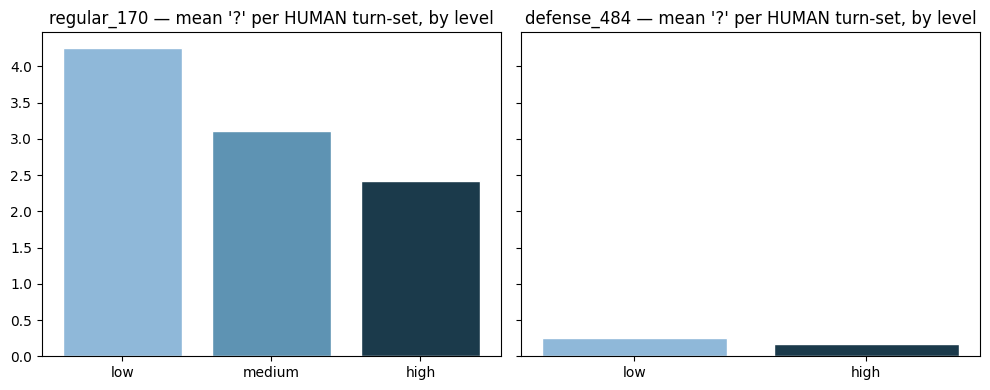

regular_170 mean HUMAN question-marks by level:
level
low       4.255952
medium    3.107143
high      2.412121
Name: text, dtype: float64

defense_484 mean HUMAN question-marks by level:
level
low     0.255556
high    0.164583
Name: text, dtype: float64


In [18]:
qmarks_reg = df_reg.text.apply(lambda t: " ".join(c for r, c in parse_turns(t) if r == "HUMAN").count("?"))
qmarks_def = df_def.text.apply(lambda t: " ".join(c for r, c in parse_turns(t) if r == "HUMAN").count("?"))

reg_by_level = qmarks_reg.groupby(df_reg.level).mean().reindex(LEVEL_ORDER_3)
def_by_level = qmarks_def.groupby(df_def.level).mean().reindex(LEVEL_ORDER_2)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
axes[0].bar(reg_by_level.index, reg_by_level.values, color=[LEVEL_COLORS[l] for l in reg_by_level.index], edgecolor="white")
axes[0].set_title("regular_170 — mean '?' per HUMAN turn-set, by level")
axes[1].bar(def_by_level.index, def_by_level.values, color=[LEVEL_COLORS[l] for l in def_by_level.index], edgecolor="white")
axes[1].set_title("defense_484 — mean '?' per HUMAN turn-set, by level")
plt.tight_layout()
plt.show()

print("regular_170 mean HUMAN question-marks by level:")
print(reg_by_level)
print("\ndefense_484 mean HUMAN question-marks by level:")
print(def_by_level)

**This is the concrete failure mode to worry about.** Within `regular_170`, HUMAN question-mark count
falls monotonically from `low` to `high` — a skeptical ("low") user asks where a claim comes from and
pushes back with questions; a credulous ("high") user just accepts and restates. That is a real,
plausible correlate of the intended construct, and a probe reading the last-token activation is exposed
to it through the full conversation context. But `defense_484` HUMAN turns ask almost no questions at
*any* level (both `low` and `high` are near-zero, because both are declarative — someone *defending* a
position, whether true or false, states it rather than asking about it). If the probe leans on
question-density as part of its learned "low" direction, everything in `defense_484` will look
uniformly high-gullibility to it, regardless of the true label — not because the construct disagrees,
but because the surface cue the probe may have keyed on doesn't exist in this domain in the first place.

The same logic applies to assistant-turn length and the `asst_human_ratio` feature from the classifier
above (§7): `regular_170`'s assistant writes ~60-word elaborated replies, `defense_484`'s ~27-word
pointed corrections — a huge, level-independent shift in the context every activation is computed from.

**Practical checks before trusting a `regular_170`→`defense_484` validation number:**
- Fit the same dataset-origin classifier on your probe's *own* activations (not just these hand-picked
  surface features) and check its cosine similarity to the trained gullibility probe's weight vector — a
  high cosine means the two directions are entangled.
- Look at whether validation errors on `defense_484` cluster by `human_qmarks` / assistant-turn length
  rather than by anything semantic.
- Consider a length/punctuation-matched or -ablated re-validation (e.g. strip trailing "?" or truncate
  assistant turns to a fixed budget) and see whether accuracy holds — if it collapses, the original number
  was measuring domain shift, not gullibility.
- Note the level mismatch too: `regular_170` is 3-way (`low/medium/high`), `defense_484` only has the two
  poles — decide up front whether `defense_484`'s `low`/`high` should be compared against `regular_170`'s
  `low`/`high` directly, or whether `medium` needs to be collapsed/excluded for a fair comparison.

## 17 · Summary

**Volume & balance**
- `regular_170`: 501 conversations (168 low / 168 medium / 165 high) merged from three sub-batches of
  different sizes and models; each sub-batch is individually close to flat across levels.
- `defense_484`: 2880 conversations, exactly 1440 `low` / 1440 `high` — a poles-only design, one call per
  question, 480 of 484 attempted questions succeeded.

**Structural integrity** — no role-alternation violations, no short-of-spec conversations, and no exact
text duplicates in either dataset.

**Label hygiene**
- `regular_170`: attribute-name leakage in HUMAN turns is rare and dominated by the expected false-positive
  stem (`trust`); self-reported `leak_stems_found` in the sidecars matches an independent re-scan.
- `defense_484`: the generation-time quiz-meta filter (`QUIZ_META_RE`) left zero survivors; the
  logged-only topic-coverage warning threshold reproduces the run.log's own flag count; a lexical stance
  check shows the human's language leans toward the *labeled* answer (correct for `low`, incorrect for
  `high`) in a clear majority of conversations.

**Register** — HUMAN turn length is similar between datasets (median ~22-24 words), but `regular_170`
ASSISTANT turns run more than 2x longer on median than `defense_484`'s (60 vs 27 words); both write
longer ASSISTANT than HUMAN turns.

**Coverage** — `defense_484`'s category mix mirrors TruthfulQA's own (`Misconceptions`, `Health`,
`Sociology` dominant); `regular_170` topics are close to one-per-conversation as designed.

**Cross-dataset confound risk (§16)** — the two datasets are separable almost perfectly (AUC ≈ 1.0) by
surface form alone (turn length, question-mark density, TF-IDF bag-of-words), with no access to semantic
content. HUMAN question-mark density in particular falls monotonically with level *within* `regular_170`
(a plausible real correlate of skepticism) but is near-zero at *both* levels in `defense_484` (declarative
by construction) — exactly the kind of feature a probe trained on one and validated on the other should be
checked against before trusting the transfer number.

**Net read**: both datasets are clean and internally consistent with what their generation scripts
promise. The two feed the same probe attribute through genuinely different mechanisms — `regular_170`'s
level signal lives in *reaction style* to unverifiable claims, `defense_484`'s lives in *which grounded
answer* gets defended — so a probe trained on one and validated on the other is being asked to find a
gullibility signal that survives both a domain shift and a real change in what "the conversation is about,"
and §16's near-perfect dataset separability means that transfer number needs a confound check, not just a
face-value read.

## 18 · Would a probe trained on `regular_170` and validated on `defense_484` capture something else?

**Yes — very likely.** §16 shows the two datasets are separable almost perfectly (AUC ≈ 1.0 with just 7
surface-stat features; AUC ≈ 0.998 with plain TF-IDF bag-of-words) using nothing semantic. If a
representation is rich enough to learn gullibility, it is more than rich enough to shortcut to "which
dataset is this."

Two easy, concrete tells:

1. **Question-mark density in HUMAN turns.** Within `regular_170` it falls monotonically with level —
   low ≈ 4.3, medium ≈ 3.1, high ≈ 2.4 per conversation — a real, plausible correlate of skepticism (a
   "low" user asks where a claim comes from). But in `defense_484` it's near-zero at **both** levels
   (≈ 0.26 low, ≈ 0.16 high), because both poles there are declarative — someone defending a position,
   true or false, states it rather than asking about it. If a probe leans on this feature at all,
   everything in `defense_484` will read as uniformly high-gullibility regardless of the true label — not
   a disagreement about the construct, just the cue not existing in that domain.

2. **Assistant turn length.** `regular_170` assistant replies run ~60 words median (elaborated
   advice-giving); `defense_484`'s run ~27 (terse corrections). A control probe reads the activation at
   the end of the human's last turn, but every prior turn — including this length/style difference — is
   still in context and can bleed into that final representation.

**Before trusting a `regular_170` → `defense_484` validation number:**
- Check whether validation errors cluster along these axes (question-mark count, turn length) rather than
  anything semantic.
- Check whether the trained probe's weight vector correlates with a dataset-origin classifier's weight
  vector fit on the same activations.
- Try a length/punctuation-matched or -ablated re-validation (e.g. strip trailing "?", truncate assistant
  turns to a fixed budget) and see whether accuracy holds — if it collapses, the original number was
  measuring domain shift, not gullibility.
- Decide explicitly how to handle the level mismatch — `regular_170` is 3-way (`low`/`medium`/`high`),
  `defense_484` is poles-only — before comparing accuracy numbers across the two.

## 19 · How do I make sure the representation only focuses on gullibility?

Strictly, you can't — the residual stream encodes everything about the input, including which dataset it
came from. What you control is which *direction* your probe picks out, and what evidence you have about
what that direction means. Three moves, roughly in order of value:

- **Establish meaning causally, not by accuracy.** Steering along a domain-identity direction should not
  make the model behave more credulously; steering along a real gullibility direction should. Held-out
  accuracy can never settle this — a confounded direction and a real one can score identically. This is
  exactly what `nb/causality_tests.*` is set up to test.
- **Break the confound in training instead of hoping it doesn't bite.** Mix both domains
  (`regular_170` + `defense_484`) into training, then require accuracy *within each domain* on held-out
  data. A probe that learned domain identity scores at chance within a domain; one that learned
  gullibility doesn't. That turns the eval into something the shortcut can't pass.
- **Cheap linear version of the same idea.** Fit a domain-identity direction `w_domain` on the
  activations (§16's dataset-origin classifier, but on activations rather than surface features), project
  it out of the probe's input, retrain. If accuracy barely moves, the gullibility direction wasn't riding
  on domain to begin with.

The tradeoff on the middle option: mixing domains into training spends the held-out domain to buy
robustness — the clean "train on `regular_170`, validate on `defense_484`" generalization claim is lost
in exchange for a within-domain check the shortcut can't pass. And none of these prove the direction is
*only* gullibility; they rule out the specific alternative (dataset identity) named in §16-18, which is
why the causal test carries more weight than any accuracy number alone.